<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 10 : K-Nearest Neighbors

1. KNN
2. Lazy Learning
3. Distance Metrics
    • Euclidean
    • Manhattan
    • Minkowski
    • Cosine
4. Choosing K
5. Voting
6. Weighted KNN
7. KD Tree
8. Ball Tree
9. Curse of Dimensionality
10. Hyperparameters
11. Detailed Python implementation (Dataset : Breast Cancer + Wine)
12. Comparison with SVM
13. Interview Questions

## Explain K-Nearest Neighbors (KNN)

### Subtask:
Provide a detailed explanation of KNN, covering its purpose, definition, intuition, mathematical foundation, formulas, a numerical example, Python implementation of the core concept, pros and cons, comparison with similar algorithms, and potential extensions. Each point will be explained with 10 subtopics.

### 1. Why we need K-Nearest Neighbors (KNN)

#### A. Simplicity and Interpretability:

*   **Why Needed:** In many machine learning scenarios, especially for beginners or when working with less complex datasets, a simple and easily interpretable model is highly desirable. KNN, being a non-parametric and instance-based algorithm, fits this need perfectly.
*   **Explanation:** KNN's decision-making process is transparent: to classify a new point, it simply looks at its closest neighbors. There's no complex model to interpret; the decision is directly derived from the training data itself. This makes it straightforward to understand *why* a particular prediction was made, which is crucial for building trust in the model.

#### B. Non-parametric Nature (No Assumptions about Data Distribution):

*   **Why Needed:** Many powerful algorithms, such as Linear Regression or Naive Bayes, make strong assumptions about the underlying distribution of the data (e.g., linearity, normality, independence of features). If these assumptions are violated, the model's performance can suffer significantly.
*   **Explanation:** KNN is a 'non-parametric' algorithm, meaning it does not make any assumptions about the functional form of the relationship between features and the target variable, nor does it assume a specific distribution for the data. This flexibility is a huge advantage when dealing with complex, irregular, or unknown data distributions, making it applicable to a wide range of real-world problems where parametric models might fail.

#### C. Adaptability to Complex Decision Boundaries:

*   **Why Needed:** In real-world data, classification boundaries are often non-linear and intricate. Linear models struggle to capture these complexities, leading to underfitting.
*   **Explanation:** Since KNN classifies a point based on its local neighborhood, it can naturally adapt to arbitrary and complex decision boundaries. Instead of trying to find a single global decision rule, KNN effectively creates a localized, flexible boundary. This ability makes it a powerful tool for datasets where classes are not easily separable by simple lines or planes.

#### D. Versatility for Both Classification and Regression:

*   **Why Needed:** A single algorithm capable of handling both prediction types can simplify the model selection process for data scientists.
*   **Explanation:** KNN is a versatile algorithm. For classification tasks, it uses a majority vote among its neighbors. For regression tasks, it typically averages the values of its neighbors. This dual capability means it can be applied to a broader spectrum of predictive modeling problems without needing to switch to entirely different algorithmic paradigms.

#### E. No Training Phase (Lazy Learning):

*   **Why Needed:** For datasets that are constantly updated or where new data comes in frequently, a model that doesn't require a time-consuming retraining phase can be highly beneficial.
*   **Explanation:** KNN is a 'lazy learner'. Unlike 'eager learners' (like Decision Trees or SVMs) that build a generalized model from the training data *before* making predictions, KNN simply stores the entire training dataset. All computation, such as distance calculation and voting, is performed only at the time of prediction. This means the 'training phase' is essentially non-existent, making it quick to 'train' and easy to update with new data.

### 2. Definition of K-Nearest Neighbors (KNN)

#### A. Formal Definition:

K-Nearest Neighbors (KNN) is a non-parametric, instance-based, supervised machine learning algorithm that can be used for both **classification** and **regression** tasks. It operates on the principle that 'similar things exist in close proximity'. The algorithm's core idea is to classify or predict the value of a new data point based on the labels or values of its 'K' closest neighbors in the feature space of the training dataset.

#### B. Key Characteristics in Definition:

*   **Non-parametric:** This means KNN makes no underlying assumptions about the distribution of the data. It doesn't learn a specific function mapping inputs to outputs but rather relies directly on the data itself.
*   **Instance-based (or Memory-based/Lazy Learner):** Instead of explicitly learning a model during a 'training phase', KNN simply memorizes the entire training dataset. All computation, such as finding neighbors and making predictions, is deferred until a query point needs to be classified or its value predicted.
*   **Supervised Learning:** KNN requires labeled training data (i.e., data points with known classes for classification or known values for regression) to make predictions for new, unlabeled data.
*   **Distance-Based:** The concept of 'proximity' or 'closeness' is central to KNN. It relies on a chosen distance metric (e.g., Euclidean, Manhattan) to quantify the similarity between data points.
*   **K (Number of Neighbors):** This is a user-defined positive integer that specifies how many neighbors will be considered when making a prediction. The choice of K is crucial and can significantly impact the model's performance.

#### C. How it "Defines" a Prediction:

*   **For Classification:** Given a new, unseen data point, KNN identifies its `K` nearest neighbors from the training set. The new data point is then assigned the class label that is most frequent among these `K` neighbors (i.e., a majority vote).

*   **For Regression:** For a new data point, KNN identifies its `K` nearest neighbors. The predicted value for the new data point is typically the average (mean) or median of the target values of these `K` neighbors.

In essence, KNN defines the characteristic of a new data point by the predominant characteristic of its closest known peers.

### 3. Intuition Behind K-Nearest Neighbors (KNN)

#### A. Analogy: Judging a Book by its Cover, or a Person by their Friends

Imagine you meet a new person, and you want to understand their personality or interests. A common approach is to look at their closest friends. If most of their friends are artists, you might intuit that this new person is also artistic. If their friends are mostly athletes, you might infer they are athletic. This simple human tendency is the core intuition behind KNN.

Similarly, imagine you have a collection of objects (say, fruits) and you find a new, unfamiliar fruit. To classify it, you naturally look at its nearest counterparts. If the new fruit looks most like apples in terms of color, size, and texture, you'd likely classify it as an apple.

#### B. Core Idea: Proximity Implies Similarity

The fundamental intuition of KNN is based on the assumption that **data points that are close to each other in the feature space are likely to be similar and belong to the same class or have similar values.** This is often referred to as the 'locality principle' or 'neighborhood-based classification'.

When a new, unclassified data point arrives:

1.  **"Who are your friends?" (Measure Proximity):** The algorithm calculates how 'close' or 'similar' this new data point is to *every single* data point in the training dataset. This 'closeness' is quantified using a chosen distance metric (e.g., Euclidean distance for continuous data).

2.  **"Identify your closest friends" (Identify Neighbors):** It then identifies the `K` data points from the training set that have the smallest distances to the new data point. These `K` points form the 'neighborhood' of the new point.

3.  **"What are your friends like?" (Vote/Average):**
    *   **For Classification:** The new data point is assigned to the class that is most represented (most frequent) among its `K` nearest neighbors. It's a 'majority vote' from the local neighborhood.
    *   **For Regression:** The value for the new data point is typically determined by taking the average (mean) or median of the target values of its `K` nearest neighbors.

#### C. Visualizing the Intuition:

Consider a 2D scatter plot where points are colored by their class. When you introduce a new, uncolored point:

*   If `K=1`, you find the single closest point and assign its class.
*   If `K=3`, you draw a small circle around the new point that encompasses its 3 closest neighbors. You then count the classes of these 3 points and assign the majority class.

The size of this 'neighborhood' (controlled by `K`) dictates how local or global the influence on the new point's classification will be. A small `K` focuses on very local patterns, while a large `K` considers a broader neighborhood.

### 4. Mathematical Foundation and Formulas

The core mathematical foundation of KNN lies in the concept of **distance** between data points. The algorithm relies on calculating how 'close' one data point is to another in a multi-dimensional feature space. The choice of distance metric is crucial as it dictates how similarity is measured.

Let's assume we have two data points, $P_1$ and $P_2$, in an $n$-dimensional space:
$P_1 = (x_{1,1}, x_{1,2}, ..., x_{1,n})$
$P_2 = (x_{2,1}, x_{2,2}, ..., x_{2,n})$

#### A. Euclidean Distance (L2 Norm)
This is the most common and intuitive distance metric. It represents the shortest straight-line distance between two points in Euclidean space.

**Formula:**
$d(P_1, P_2) = \sqrt{\sum_{i=1}^{n} (x_{1,i} - x_{2,i})^2}$

**Intuition:** Imagine a straight line connecting two points; its length is the Euclidean distance.

#### B. Manhattan Distance (L1 Norm or Taxicab Distance)
This metric calculates the sum of the absolute differences between the coordinates of the two points. It's like navigating city blocks, where you can only move horizontally or vertically.

**Formula:**
$d(P_1, P_2) = \sum_{i=1}^{n} |x_{1,i} - x_{2,i}|$

**Intuition:** The distance a taxi would travel along a grid-like street plan from one point to another.

#### C. Minkowski Distance
The Minkowski distance is a generalization of both Euclidean and Manhattan distances. It is parameterized by a value $p$.

**Formula:**
$d(P_1, P_2) = \left( \sum_{i=1}^{n} |x_{1,i} - x_{2,i}|^p \right)^{1/p}$

*   When $p=1$, it becomes the Manhattan distance.
*   When $p=2$, it becomes the Euclidean distance.
*   As $p \to \infty$, it becomes the Chebyshev distance (maximum coordinate difference).

**Intuition:** A flexible way to define distance, allowing tuning of the 'path' between points.

#### D. Cosine Similarity (and Cosine Distance)
Cosine similarity measures the cosine of the angle between two non-zero vectors. It indicates whether two vectors are pointing in roughly the same direction. It's often used when the magnitude of the vectors doesn't matter, but their orientation does (e.g., in text analysis to compare document similarity).

**Formula (Cosine Similarity):**
$similarity(P_1, P_2) = \frac{P_1 \cdot P_2}{||P_1|| \cdot ||P_2||} = \frac{\sum_{i=1}^{n} (x_{1,i} \cdot x_{2,i})}{\sqrt{\sum_{i=1}^{n} x_{1,i}^2} \cdot \sqrt{\sum_{i=1}^{n} x_{2,i}^2}}$

**Formula (Cosine Distance):**
$d(P_1, P_2) = 1 - similarity(P_1, P_2)$

**Intuition:** If two vectors are perfectly aligned (angle = 0 degrees), their similarity is 1. If they are orthogonal (angle = 90 degrees), their similarity is 0. If they are diametrically opposed (angle = 180 degrees), their similarity is -1. Cosine distance converts this similarity into a distance measure.

### 5. Numerical Example of KNN Classification

Let's walk through a simple numerical example to understand how KNN classifies a new data point.

**Scenario:** We have a dataset of fruits with two features: `Sweetness` and `Crunchiness`, and we want to classify whether a new fruit is an `Apple` or an `Orange`.

**Training Data:**

| Fruit   | Sweetness (X1) | Crunchiness (X2) | Type    |
| :------ | :------------- | :--------------- | :------ |
| Fruit A | 7              | 7                | Apple   |
| Fruit B | 7              | 4                | Orange  |
| Fruit C | 3              | 4                | Orange  |
| Fruit D | 1              | 4                | Orange  |
| Fruit E | 4              | 7                | Apple   |
| Fruit F | 6              | 2                | Orange  |

**New Data Point to Classify (Query Point):**
`New Fruit P`: `Sweetness = 3`, `Crunchiness = 7`

**Chosen K Value:** `K = 3` (We will consider the 3 nearest neighbors).

**Distance Metric:** Euclidean Distance.

---

**Steps:**

1.  **Calculate Distance to Every Training Data Point:**
    We will calculate the Euclidean distance between `New Fruit P (3, 7)` and each fruit in the training data.

    *   **Distance (P, Fruit A)**: $\sqrt{(3-7)^2 + (7-7)^2} = \sqrt{(-4)^2 + 0^2} = \sqrt{16} = 4$
    *   **Distance (P, Fruit B)**: $\sqrt{(3-7)^2 + (7-4)^2} = \sqrt{(-4)^2 + 3^2} = \sqrt{16 + 9} = \sqrt{25} = 5$
    *   **Distance (P, Fruit C)**: $\sqrt{(3-3)^2 + (7-4)^2} = \sqrt{0^2 + 3^2} = \sqrt{9} = 3$
    *   **Distance (P, Fruit D)**: $\sqrt{(3-1)^2 + (7-4)^2} = \sqrt{2^2 + 3^2} = \sqrt{4 + 9} = \sqrt{13} \approx 3.61$
    *   **Distance (P, Fruit E)**: $\sqrt{(3-4)^2 + (7-7)^2} = \sqrt{(-1)^2 + 0^2} = \sqrt{1} = 1$
    *   **Distance (P, Fruit F)**: $\sqrt{(3-6)^2 + (7-2)^2} = \sqrt{(-3)^2 + 5^2} = \sqrt{9 + 25} = \sqrt{34} \approx 5.83$

2.  **Order Distances and Identify K-Nearest Neighbors:**
    Now, we list the fruits by their distance to `New Fruit P` in ascending order:

    | Fruit   | Distance | Type    |
    | :------ | :------- | :------ |
    | Fruit E | 1        | Apple   |
    | Fruit C | 3        | Orange  |
    | Fruit D | 3.61     | Orange  |
    | Fruit A | 4        | Apple   |
    | Fruit B | 5        | Orange  |
    | Fruit F | 5.83     | Orange  |

    Since `K = 3`, our 3 nearest neighbors are:
    *   Fruit E (Distance = 1, Type = Apple)
    *   Fruit C (Distance = 3, Type = Orange)
    *   Fruit D (Distance = 3.61, Type = Orange)

3.  **Vote for the Class:**
    Count the occurrences of each class among the 3 nearest neighbors:
    *   Apple: 1 (Fruit E)
    *   Orange: 2 (Fruit C, Fruit D)

    The majority class is `Orange`.

---

**Conclusion:** Based on the KNN algorithm with `K=3`, the `New Fruit P` is classified as an **Orange**.

### 6. Python Implementation of Core KNN Concept

To fully grasp the mechanics of KNN, let's implement the core algorithm from scratch using Python. This implementation will cover:

1.  **Distance Calculation:** A function to compute the Euclidean distance between two points.
2.  **Neighbor Identification:** A function to find the `K` nearest neighbors for a given query point.
3.  **Prediction (Voting):** A function to determine the class of the query point based on the majority vote of its neighbors.

This implementation will use the same `training_data`, `training_labels`, and `query_point` from our numerical example.

In [2]:
import numpy as np
from collections import Counter

# 1. Define Euclidean Distance Function
def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points."""
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

# 2. Define KNN Classifier Function
def knn_classify(training_data, training_labels, query_point, k):
    """Classifies a query point using the K-Nearest Neighbors algorithm."""
    distances = []
    for i, data_point in enumerate(training_data):
        dist = euclidean_distance(query_point, data_point)
        distances.append((dist, training_labels[i]))

    # Sort by distance and get the k nearest neighbors
    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]

    # Get the labels of the k nearest neighbors
    neighbor_labels = [label for dist, label in k_nearest_neighbors]

    # Vote for the most common label
    most_common = Counter(neighbor_labels).most_common(1)
    return most_common[0][0]

# --- Our numerical example data ---
# Training features (Sweetness, Crunchiness)
training_data = [
    [7, 7], # Fruit A
    [7, 4], # Fruit B
    [3, 4], # Fruit C
    [1, 4], # Fruit D
    [4, 7], # Fruit E
    [6, 2]  # Fruit F
]

# Corresponding training labels
training_labels = ['Apple', 'Orange', 'Orange', 'Orange', 'Apple', 'Orange']

# New data point to classify (Sweetness=3, Crunchiness=7)
query_point = [3, 7]

# Chosen K value
k_value = 3

# Perform classification using our custom KNN function
predicted_class = knn_classify(training_data, training_labels, query_point, k_value)

print(f"New Fruit P ({query_point}) is classified as: {predicted_class}")

# Example for a different K value
k_value_5 = 5
predicted_class_5 = knn_classify(training_data, training_labels, query_point, k_value_5)
print(f"\nWith K = {k_value_5}, New Fruit P ({query_point}) is classified as: {predicted_class_5}")

New Fruit P ([3, 7]) is classified as: Orange

With K = 5, New Fruit P ([3, 7]) is classified as: Orange


### 7. Explanation of the Python Code for KNN

The Python code provided in the previous cell demonstrates a basic implementation of the K-Nearest Neighbors algorithm from scratch. Let's break down each part of the code to understand its functionality.

#### A. `euclidean_distance(point1, point2)` Function

*   **Purpose:** This function is responsible for calculating the Euclidean distance between any two given data points. As discussed in the 'Mathematical Foundation' section, Euclidean distance is a common metric to quantify the 'closeness' or 'similarity' between points.
*   **Explanation:**
    *   It takes two lists or arrays, `point1` and `point2`, representing the coordinates of the two data points.
    *   `np.array(point1) - np.array(point2)` calculates the difference between corresponding coordinates of the two points. This results in an array of differences.
    *   `**2` squares each of these differences.
    *   `np.sum(...)` adds up all the squared differences.
    *   `np.sqrt(...)` takes the square root of the sum, which gives the final Euclidean distance.

#### B. `knn_classify(training_data, training_labels, query_point, k)` Function

*   **Purpose:** This is the main function that encapsulates the KNN classification logic. It takes the training dataset, its labels, a new point to classify, and the value of `K`.
*   **Explanation:**
    1.  **Calculate Distances:**
        *   It initializes an empty list called `distances`.
        *   It then iterates through each `data_point` and its corresponding `training_label` in the `training_data`.
        *   For each `data_point`, it calls `euclidean_distance` to find the distance between the `query_point` and the current `data_point`.
        *   It stores a tuple `(distance, label)` in the `distances` list.
    2.  **Identify K-Nearest Neighbors:**
        *   `distances.sort(key=lambda x: x[0])` sorts the `distances` list based on the first element of each tuple (which is the distance value) in ascending order. This places the closest neighbors at the beginning of the list.
        *   `k_nearest_neighbors = distances[:k]` selects the first `k` elements from the sorted `distances` list. These are our K-nearest neighbors.
    3.  **Majority Vote for Classification:**
        *   `neighbor_labels = [label for dist, label in k_nearest_neighbors]` extracts only the class labels from the `k_nearest_neighbors` list.
        *   `Counter(neighbor_labels)` creates a dictionary-like object that counts the occurrences of each unique label in `neighbor_labels`.
        *   `.most_common(1)` returns a list of the `n` most common elements and their counts. Here, `1` means it returns only the single most common label.
        *   `[0][0]` accesses the label itself from the result (e.g., if `most_common` returns `[('Orange', 2)]`, `[0][0]` will extract `'Orange'`).

#### C. Example Data and Execution

*   The code defines `training_data` (features like Sweetness and Crunchiness) and `training_labels` (Apple or Orange) mirroring our numerical example.
*   `query_point` is the new fruit we want to classify.
*   `k_value` is set to `3` for the first classification.
*   The `knn_classify` function is called, and the `predicted_class` is printed.
*   A second example is provided with `k_value_5 = 5` to show how changing K can affect the prediction, demonstrating the robustness of the example. In this specific case, both `K=3` and `K=5` lead to the same classification for the `query_point`.

### 8. Pros and Cons of K-Nearest Neighbors (KNN)

Like any machine learning algorithm, K-Nearest Neighbors (KNN) comes with its own set of advantages and disadvantages. Understanding these can help in deciding when and where to apply KNN effectively.

#### A. Advantages (Pros)

1.  **Simplicity and Ease of Implementation:**
    *   **Explanation:** KNN is conceptually very simple. Its core idea is intuitive (finding the nearest neighbors and voting), making it easy to understand and implement from scratch. It's often one of the first algorithms taught in machine learning courses.

2.  **No Training Phase (Lazy Learner):**
    *   **Explanation:** KNN is a 'lazy learner' or 'instance-based learning' algorithm. It doesn't learn a discriminative function from the training data during a dedicated training phase. Instead, it simply stores the entire training dataset and performs computations only when a prediction is needed. This makes it very fast to 'train'.

3.  **Non-parametric Nature:**
    *   **Explanation:** KNN makes no explicit assumptions about the underlying distribution of the data (e.g., linearity, normality). This flexibility is a significant advantage when dealing with complex, irregular, or unknown data distributions, making it applicable to a wide range of real-world problems where parametric models might fail.

4.  **Adaptability to Complex Decision Boundaries:**
    *   **Explanation:** Since KNN classifies based on local neighborhoods, it can naturally adapt to arbitrary and complex decision boundaries. It doesn't try to fit a single global model but rather creates localized, flexible boundaries.

5.  **Versatility for Both Classification and Regression:**
    *   **Explanation:** KNN can be used for both classification (majority vote) and regression (averaging or median) tasks, providing a single algorithmic framework for different predictive modeling problems.

6.  **Good for Multi-Class Problems:**
    *   **Explanation:** KNN inherently handles multi-class classification problems without needing any specific modifications or strategies (like one-vs-rest or one-vs-one often required by algorithms like SVM).

#### B. Disadvantages (Cons)

1.  **Computationally Expensive Prediction Phase:**
    *   **Explanation:** While 'training' is fast, the prediction phase can be very slow, especially with large datasets. For every new query point, KNN must calculate its distance to *every single* training data point. This makes it inefficient for real-time predictions on massive datasets.

2.  **Memory Intensive:**
    *   **Explanation:** KNN needs to store the entire training dataset in memory (or have quick access to it) for prediction. This can be a significant limitation for datasets with many features or many training examples.

3.  **Sensitive to Irrelevant Features:**
    *   **Explanation:** KNN considers all features equally when calculating distances. If there are many irrelevant or noisy features, they can disproportionately influence the distance calculation, leading to poor performance. Feature selection or dimensionality reduction techniques are often necessary.

4.  **Sensitive to Feature Scaling:**
    *   **Explanation:** Features with larger ranges can dominate the distance calculation, regardless of their actual importance. Therefore, proper feature scaling (e.g., normalization or standardization) is almost always required before applying KNN.

5.  **Choice of K Value is Crucial:**
    *   **Explanation:** The performance of KNN is highly dependent on the choice of `K`. A small `K` can make the model sensitive to noise and outliers (high variance), while a large `K` can smooth out the decision boundaries too much, potentially leading to misclassifications for points near class boundaries (high bias). Choosing an optimal `K` often requires cross-validation.

6.  **Imbalanced Data Sensitivity:**
    *   **Explanation:** With imbalanced datasets (where one class significantly outnumbers others), KNN tends to be biased towards the majority class. If the `K` neighbors are predominantly from the majority class, the minority class points are often misclassified.

7.  **Curse of Dimensionality:**
    *   **Explanation:** In high-dimensional spaces (datasets with many features), the concept of 'distance' becomes less meaningful. All points tend to appear 'far' from each other, and the distinction between the closest and farthest neighbors diminishes. This makes it difficult to find truly 'nearest' neighbors and can significantly degrade KNN's performance. (We will discuss the Curse of Dimensionality in more detail later).

### 9. Comparison with Previous or Similar Algorithms/Models

To better understand K-Nearest Neighbors (KNN), it's helpful to compare it with other machine learning algorithms. This highlights KNN's strengths and weaknesses in different contexts.

#### A. KNN vs. Linear Models (e.g., Logistic Regression, Linear SVM)

*   **KNN:**
    *   **Nature:** Non-parametric, instance-based. No assumptions about data distribution.
    *   **Decision Boundary:** Can learn highly complex and non-linear decision boundaries. It's locally defined.
    *   **Interpretability:** Relatively high due to its simplicity (it's based on neighbors).
    *   **Computation:** Heavy at prediction time (needs to compute distances to all training points).
    *   **Data Requirements:** Requires all training data to be available at prediction time.
    *   **Feature Sensitivity:** Highly sensitive to feature scaling and irrelevant features.
    *   **Dimensionality:** Suffers from the curse of dimensionality.

*   **Linear Models (e.g., Logistic Regression):**
    *   **Nature:** Parametric, eager learner. Assumes a linear relationship between features and target (or a linear decision boundary).
    *   **Decision Boundary:** Creates a simple, linear decision boundary.
    *   **Interpretability:** High, as coefficients often indicate feature importance.
    *   **Computation:** Fast at prediction time once coefficients are learned during training.
    *   **Data Requirements:** Once trained, only the learned coefficients (model parameters) are needed for prediction.
    *   **Feature Sensitivity:** Less sensitive to individual noisy features if they don't significantly impact the linear relationship. Feature scaling is often still beneficial.
    *   **Dimensionality:** Can perform well in high dimensions if the relationships are genuinely linear, but still prone to issues with collinearity.

*   **Key Difference:** KNN is flexible with complex patterns but slow for prediction, while linear models are fast for prediction (after training) but rigid with complex, non-linear data.

#### B. KNN vs. Decision Trees

*   **KNN:**
    *   **Nature:** Non-parametric, instance-based, lazy learner.
    *   **Decision Boundary:** Smooth and highly adaptable, locally defined.
    *   **Interpretability:** Relatively simple, based on neighbors.
    *   **Feature Sensitivity:** Highly sensitive to feature scaling and irrelevant features.
    *   **Data Handling:** Does not handle categorical features directly without encoding. Requires numerical input.

*   **Decision Trees:**
    *   **Nature:** Non-parametric, rule-based, eager learner.
    *   **Decision Boundary:** Piecewise constant and axis-parallel (rectangular regions).
    *   **Interpretability:** Often very high (can be visualized as a flowchart of decisions).
    *   **Feature Sensitivity:** Generally robust to feature scaling (splits are based on thresholds). Can handle irrelevant features to some extent but might grow unnecessarily complex.
    *   **Data Handling:** Can handle both numerical and categorical features directly.

*   **Key Difference:** Decision Trees build explicit, interpretable rules, while KNN uses implicit rules based on local neighborhoods. KNN's decision boundaries are smoother than the step-like boundaries of Decision Trees.

#### C. KNN vs. Support Vector Machines (SVM)

*   **KNN:**
    *   **Nature:** Instance-based, lazy learner.
    *   **Decision Boundary:** Adapts to local data patterns.
    *   **Training Time:** No explicit training phase.
    *   **Prediction Time:** Slow for large datasets.
    *   **Memory:** High, stores all training data.
    *   **Outliers:** Sensitive to noisy data and outliers.

*   **SVM:**
    *   **Nature:** Eager learner, finds an optimal hyperplane.
    *   **Decision Boundary:** Learns a global optimal separating hyperplane (or non-linear boundary with kernels).
    *   **Training Time:** Can be computationally intensive during training, especially with large datasets or complex kernels.
    *   **Prediction Time:** Fast once trained (only support vectors are needed).
    *   **Memory:** Only needs to store support vectors for prediction (potentially much less than the whole dataset).
    *   **Outliers:** Less sensitive to outliers, as it focuses on the margin and support vectors.

*   **Key Difference:** SVM learns a global decision boundary during training, making predictions fast. KNN defers all computation to prediction time, making it flexible but slow. SVM aims to maximize the margin, leading to better generalization in many cases, while KNN's local nature can make it prone to noise.

### 10. Extensions and Enhancements to K-Nearest Neighbors (KNN)

While the basic KNN algorithm is simple and effective, several extensions and enhancements have been developed to address its limitations, particularly regarding computational efficiency, sensitivity to noise, and handling of imbalanced data.

#### A. Weighted K-Nearest Neighbors (WKNN)

*   **Why Needed:** In standard KNN, all `K` neighbors contribute equally to the classification or regression decision. However, closer neighbors are intuitively more relevant than farther ones. WKNN addresses this.
*   **Concept:** Instead of a simple majority vote (for classification) or average (for regression), WKNN assigns weights to each of the `K` neighbors. The weight is typically inversely proportional to the distance of the neighbor from the query point. This means closer neighbors have a greater influence on the final prediction.
*   **Formula (Classification - Weighted Vote):**
    The prediction for a class $C_j$ is given by:
    $P(C_j | x_q) = \frac{\sum_{i=1}^{K} w_i \cdot I(y_i = C_j)}{\sum_{i=1}^{K} w_i}$
    Where $x_q$ is the query point, $y_i$ is the label of neighbor $i$, $I(\cdot)$ is the indicator function (1 if true, 0 if false), and $w_i$ is the weight of neighbor $i$.
    Common weighting functions include:
    *   Inverse distance: $w_i = \frac{1}{d(x_q, x_i)}$
    *   Inverse squared distance: $w_i = \frac{1}{d(x_q, x_i)^2}$
    *   Gaussian kernel: $w_i = e^{-d(x_q, x_i)^2 / \sigma^2}$
*   **Benefit:** Reduces the impact of distant (and potentially noisy) neighbors and improves prediction accuracy in many cases.

#### B. KD-Trees (K-Dimensional Trees)

*   **Why Needed:** The most significant bottleneck of KNN is the need to compute distances to all training points for each query. For large datasets, this becomes computationally prohibitive. KD-Trees provide a way to speed up neighbor search.
*   **Concept:** A KD-Tree is a space-partitioning data structure that organizes points in a k-dimensional space. It recursively divides the data space into smaller regions (hyperrectangles) by splitting along one dimension at each node, cycling through dimensions.
*   **How it works:** When searching for nearest neighbors, the KD-Tree can efficiently prune large portions of the search space that are guaranteed not to contain the nearest neighbors, significantly reducing the number of distance calculations required.
*   **Benefit:** Dramatically speeds up the neighbor search process, making KNN feasible for larger datasets.
*   **Limitation:** Performance degrades in very high-dimensional spaces (Curse of Dimensionality), where the tree becomes unbalanced and less effective at pruning.

#### C. Ball Trees

*   **Why Needed:** Similar to KD-Trees, Ball Trees are designed to optimize nearest neighbor searches, especially in higher-dimensional spaces where KD-Trees can struggle.
*   **Concept:** A Ball Tree is a data structure that recursively partitions data points into nested

## Explain Lazy Learning

KNN is often referred to as a 'Lazy Learner'. To fully appreciate this aspect and other algorithms that fall into this category, it's essential to understand what Lazy Learning means, its implications, and its contrast with 'Eager Learning'.

### 1. Why we need Lazy Learning

#### A. Adaptability to Evolving Data:

*   **Why Needed:** In many real-world applications, data is not static. New observations arrive constantly, and the underlying patterns might shift over time (concept drift). Algorithms that require extensive retraining with every data update can be cumbersome and computationally expensive.
*   **Explanation:** Lazy learners, by deferring all computation to the prediction phase, naturally adapt to evolving data. When new data points are added to the dataset, they are simply stored, and no prior 'model' needs to be re-built. This makes them highly suitable for dynamic environments where the data distribution changes frequently or where real-time updates are critical, as the 'model' is always up-to-date with the latest information without explicit retraining.

#### B. Handling Complex and Irregular Decision Boundaries:

*   **Why Needed:** As discussed with KNN, real-world data often exhibits complex, non-linear relationships that are difficult to model with fixed parametric functions. Eager learners try to generalize these patterns globally.
*   **Explanation:** Lazy learning, being instance-based, can capture highly intricate and local patterns within the data. Instead of forcing a single, global decision boundary, it builds its 'model' locally around each query point. This ability to form arbitrary decision boundaries without making strong assumptions about the data's underlying structure is invaluable for complex datasets where traditional models might oversimplify the relationships.

#### C. No Prior Model Assumptions:

*   **Why Needed:** Many 'eager' algorithms (e.g., Linear Regression, Naive Bayes, Logistic Regression) assume specific functional forms or statistical distributions for the data. Violations of these assumptions can lead to poor model performance.
*   **Explanation:** Lazy learning algorithms are non-parametric; they make no a priori assumptions about the data's underlying distribution or the relationship between features and target. They learn directly from the data points themselves, making them robust when the true data-generating process is unknown or highly complex. This flexibility reduces the risk of making incorrect assumptions that could lead to a biased or ineffective model.

#### D. Localized Learning for Specific Queries:

*   **Why Needed:** Sometimes, the goal isn't to build a universal model that explains the entire dataset, but rather to provide accurate predictions for specific, localized queries. A global model might smooth over nuances that are important in a particular region of the feature space.
*   **Explanation:** Lazy learning excels at providing localized predictions. For each new query, it constructs a unique 'local model' based only on the nearest neighbors relevant to that query. This ensures that the prediction is highly tailored to the immediate vicinity of the query point, potentially leading to more accurate and context-aware predictions than a global model might offer.

#### E. Simplicity in Concept and Debugging:

*   **Why Needed:** For certain tasks or during initial data exploration, a straightforward algorithm that is easy to understand and debug can be highly advantageous. Complex models can be black boxes.
*   **Explanation:** The fundamental concept of lazy learning (just storing data and comparing it to new points) is intuitively simple. This simplicity translates to easier understanding of how predictions are made, which can be beneficial for interpreting results and identifying potential issues or outliers. Since there's no complex model to train and optimize in advance, debugging often boils down to checking distance calculations and neighbor selection.

### 2. Definition of Lazy Learning

#### A. Core Concept: Deferring Generalization

**Lazy Learning** (also known as **Instance-Based Learning** or **Memory-Based Learning**) is a machine learning approach where the generalization of the training data is *deferred* until a prediction request is made for a new, unseen data point. Unlike 'Eager Learning' algorithms that build a generalized model (e.g., a decision tree, a set of regression coefficients, or SVM hyperplanes) during a distinct training phase *before* any predictions are needed, a lazy learner simply stores the entire training dataset.

#### B. Key Characteristics in Definition:

1.  **No Explicit Training Phase:**
    *   **Explanation:** The algorithm doesn't create a generalized model or learn a set of parameters from the training data in advance. It essentially 'memorizes' all the training examples. This means the 'training time' is effectively zero, as it just involves storing the data.

2.  **Computation at Query Time (Prediction Phase):**
    *   **Explanation:** All computational effort, such as finding patterns, calculating distances, or performing local approximations, is expended only when a new query point arrives and a prediction is required. The algorithm processes the stored training data *on-demand* to answer the specific query.

3.  **Instance-Based:**
    *   **Explanation:** Predictions for new instances are made directly from the stored training instances (often called 'exemplars' or 'prototypes'). The algorithm uses these specific instances to infer the output for the new query, rather than relying on a generalized abstraction of the data.

4.  **Local Approximation:**
    *   **Explanation:** Lazy learners typically make predictions based on a small, localized neighborhood of the query point in the feature space. They assume that data points close to each other are likely to have similar labels or values.

5.  **Non-Parametric (Often):**
    *   **Explanation:** Many lazy learning algorithms (like KNN) are non-parametric, meaning they do not make assumptions about the underlying data distribution or the functional form of the relationship between input features and output. This allows them to capture complex patterns that parametric models might miss.

#### C. Analogy to further clarify:

*   **Eager Learner (e.g., Decision Tree):** Imagine a student who studies for an exam by summarizing the entire textbook into a concise set of notes *before* the exam. On the exam, they refer to their pre-compiled notes to answer questions quickly.
*   **Lazy Learner (e.g., KNN):** Imagine a student who, for the same exam, doesn't summarize anything. Instead, when a question comes up, they open the textbook and search for the *most relevant paragraphs* to answer that specific question. They only do the work when asked to.

#### D. Relationship to KNN:

K-Nearest Neighbors (KNN) is the quintessential example of a lazy learning algorithm because it satisfies all these characteristics: it stores all training data, performs all computations (distance calculations, voting) only at prediction time, makes decisions based on local instances, and is non-parametric.

### 3. Intuition Behind Lazy Learning

The intuition behind lazy learning can be best understood by contrasting it with 'eager learning'.

#### A. Eager Learning Intuition: Build a Master Plan First

Imagine an **eager learner** as a meticulous planner or a general who wants to conquer a territory. Before undertaking any specific mission (making a prediction), the general spends a significant amount of time studying the entire terrain, drawing detailed maps, identifying all strategic points, and formulating a comprehensive battle plan for *all* possible scenarios.

*   **Training Phase:** The general studies all available historical data (training data) to build a universal, generalized model (the detailed map and battle plan). This model is a condensed representation of all the knowledge learned.
*   **Prediction Phase:** When a new threat or mission arises (a new query point), the general quickly consults their pre-built map and battle plan. They don't need to re-analyze the entire terrain; they just apply the relevant part of their existing plan. Predictions are fast because all the hard work was done upfront.

Examples: Decision Trees, Logistic Regression, Support Vector Machines.

#### B. Lazy Learning Intuition: Learn on the Fly, Only When Necessary

Now, imagine a **lazy learner** as an expert detective or a highly resourceful scout. This scout doesn't waste time memorizing every single detail of the entire vast wilderness upfront. Instead, they operate on a need-to-know basis.

*   **Training Phase (Storage):** The scout simply keeps a record of all their past experiences, observations, and encountered locations (stores the entire training dataset). There's no initial grand plan or model built; just a collection of raw data.
*   **Prediction Phase (Action):** When asked to make a decision or find something in a specific new location (a new query point), the scout immediately focuses *only* on the relevant surroundings. They don't consult a global map. Instead, they quickly search their memory for similar past experiences or nearby landmarks (finds the K-nearest neighbors) and uses *only that local information* to make a decision or predict the outcome for the current situation.

*   **Key Idea:** The 'intelligence' or 'model' isn't pre-baked; it emerges dynamically and locally when a query is presented. It's like having a library full of books and only reading the relevant chapters when a specific question needs an answer, rather than trying to summarize all books beforehand.

#### C. Example with KNN:

For a new data point, a lazy learner like KNN doesn't refer to a pre-defined boundary line or a set of rules. Instead, it looks at its immediate neighbors in the training data and asks: "What is the most common characteristic among my closest acquaintances?" The intuition is that the identity of a new item is best determined by the identity of the items it most closely resembles, rather than by fitting it into a global categorical framework.

### 4. Mathematical Underpinnings of Lazy Learning

While lazy learning doesn't have a single overarching mathematical 'model' like a linear regression equation or a decision tree structure, its mathematical foundation lies in its operational principles: **distance-based similarity** and **local estimation**.

Let's formalize some of these concepts.

#### A. No Explicit Model Function (f(x))

In eager learning, the goal is often to learn a function $f(x)$ that maps input features $x$ to an output $y$ ($y = f(x)$). This function is typically represented by a set of parameters $\theta$ (e.g., coefficients in linear regression, weights in a neural network) that are optimized during training. The prediction for a new point $x_q$ is simply $f(x_q, \theta)$.

In lazy learning, there is **no explicit global function $f(x)$ or set of parameters $\theta$** that is learned from the entire dataset. Instead, for each query point $x_q$, a *local* model or estimation is constructed on-the-fly.

#### B. Distance Metric (as seen in KNN)

As we discussed with KNN, the core mathematical component is the **distance function** $d(x_a, x_b)$ which quantifies the dissimilarity between any two data points $x_a$ and $x_b$.

*   Given a query point $x_q$ and a training dataset $D = \{(x_i, y_i)\}_{i=1}^N$, where $x_i$ are features and $y_i$ are labels/values.
*   The first step is to compute $d(x_q, x_i)$ for all $i \in \{1, ..., N\}$.

Common distance metrics (as previously covered):
*   **Euclidean Distance (L2 norm):** $d(x_a, x_b) = \sqrt{\sum_{j=1}^{M} (x_{a,j} - x_{b,j})^2}$
*   **Manhattan Distance (L1 norm):** $d(x_a, x_b) = \sum_{j=1}^{M} |x_{a,j} - x_{b,j}|$
*   **Minkowski Distance (Lp norm):** $d(x_a, x_b) = \left( \sum_{j=1}^{M} |x_{a,j} - x_{b,j}|^p \right)^{1/p}$

#### C. Nearest Neighbor Selection

After computing distances, the next mathematical step is to identify the $K$ points from the training set $D$ that are closest to $x_q$. Let's denote the set of these $K$ nearest neighbors as $N_K(x_q)$.

$N_K(x_q) = \{ (x_i, y_i) \in D \mid (x_i, y_i) \text{ is one of the K smallest } d(x_q, x_i) \}$

#### D. Local Estimation (Prediction)

The final mathematical step involves using the labels/values of the neighbors in $N_K(x_q)$ to make a prediction for $x_q$.

**1. For Classification (Majority Vote):**
The predicted class $\hat{y}_q$ for the query point $x_q$ is the class that appears most frequently among its $K$ nearest neighbors.

$\hat{y}_q = \operatorname{argmax}_{c} \sum_{(x_i, y_i) \in N_K(x_q)} I(y_i = c)$

Where $I(\cdot)$ is the indicator function (returns 1 if the condition is true, 0 otherwise), and $c$ iterates through all possible class labels.

**2. For Regression (Average/Median):**
The predicted value $\hat{y}_q$ for the query point $x_q$ is typically the mean or median of the target values of its $K$ nearest neighbors.

$\hat{y}_q = \frac{1}{K} \sum_{(x_i, y_i) \in N_K(x_q)} y_i \quad \text{(Mean)}$

or

$\hat{y}_q = \operatorname{median}_{ (x_i, y_i) \in N_K(x_q) } y_i \quad \text{(Median)}$

#### E. No Gradient Descent or Model Optimization

A key 'absence' in the mathematics of lazy learning, distinguishing it from many eager algorithms, is the lack of a complex optimization process involving calculus, gradient descent, or iterative parameter updates. The 'learning' is effectively the storage of data, and the 'prediction' is a direct, distance-based look-up and aggregation process.

### 5. Formulas in Lazy Learning

Unlike eager learning algorithms that learn a fixed set of parameters or a global function (a single 'formula' for the entire dataset) during a training phase, lazy learning algorithms don't have a singular, universally applied formula that defines the entire model. Instead, the 'formulas' are applied *dynamically* and *locally* for each new query point, based on its nearest neighbors.

Since K-Nearest Neighbors (KNN) is the most prominent example of a lazy learning algorithm, its formulas effectively represent the core mathematical operations for this paradigm.

Let's assume we have:
*   A query point: $x_q$
*   A training dataset: $D = \{(x_i, y_i)\}_{i=1}^N$, where $x_i$ are feature vectors and $y_i$ are their corresponding labels/values.
*   A chosen number of neighbors: $K$
*   A chosen distance metric: $d(x_a, x_b)$

#### A. Step 1: Distance Calculation Formula

For each training data point $x_i \in D$, calculate its distance to the query point $x_q$. This uses the chosen distance metric. For instance, using **Euclidean Distance** (as commonly applied in KNN):

$d(x_q, x_i) = \sqrt{\sum_{j=1}^{M} (x_{q,j} - x_{i,j})^2}$

Where $M$ is the number of features (dimensions) and $x_{q,j}$ and $x_{i,j}$ are the $j$-th feature values of the query point and the $i$-th training point, respectively.

#### B. Step 2: Neighbor Selection (No Explicit Formula, but a Procedure)

This step involves a sorting and selection procedure rather than a mathematical formula. All calculated distances $d(x_q, x_i)$ are sorted in ascending order, and the $K$ training points corresponding to the smallest distances are selected. Let this set of $K$ nearest neighbors and their labels/values be denoted as $N_K(x_q) = \{ (x_{(1)}, y_{(1)}), (x_{(2)}, y_{(2)}), ..., (x_{(K)}, y_{(K)}) \}$, where $(x_{(p)}, y_{(p)})$ is the $p$-th nearest neighbor.

#### C. Step 3: Prediction Formula (Local Aggregation)

The final prediction for $x_q$ is made by aggregating the labels/values of the $K$ nearest neighbors. The 'formula' for this aggregation depends on whether it's a classification or regression task.

1. **For Classification (Majority Vote Formula):**

   The predicted class $\hat{y}_q$ for the query point $x_q$ is the class label that occurs most frequently among the $K$ nearest neighbors.

   $$
   \hat{y}_q
   =
   \operatorname*{arg\,max}_{c\in\text{Classes}}
   \left(
   \sum_{(x_{(p)},\,y_{(p)})\in N_K(x_q)}
   I(y_{(p)}=c)
   \right)
   $$

   where

   $$
   I(y_{(p)}=c)=
   \begin{cases}
   1, & \text{if } y_{(p)}=c,\\
   0, & \text{otherwise.}
   \end{cases}
   $$

   This formula counts the occurrences of each class among the $K$ nearest neighbors and selects the class with the highest count.

2. **For Regression (Averaging Formula):**

   The predicted value $\hat{y}_q$ for the query point $x_q$ is typically the mean of the target values of its $K$ nearest neighbors.

   $$
   \hat{y}_q
   =
   \frac{1}{K}
   \sum_{(x_{(p)},\,y_{(p)})\in N_K(x_q)}
   y_{(p)}
   $$

   Alternatively, the median can be used:

   $$
   \hat{y}_q
   =
   \operatorname{median}
   \left\{
   y_{(p)}
   \;\middle|\;
   (x_{(p)},\,y_{(p)})\in N_K(x_q)
   \right\}
   $$

#### Summary

These formulas are not 'learned' in advance; they are applied as a computational routine *every time* a new prediction is requested. The core mathematical structure of lazy learning revolves around these distance computations and subsequent local aggregations of neighbor information.

### 6. Numerical Example of Lazy Learning (using KNN)

Since K-Nearest Neighbors (KNN) is the quintessential example of a lazy learning algorithm, the numerical example for KNN that we previously covered effectively serves as a numerical example for the lazy learning paradigm itself. It beautifully illustrates how computation is deferred until query time.

Let's revisit the KNN numerical example to highlight the 'lazy' aspects.

**Scenario:** We have a dataset of fruits with two features: `Sweetness` and `Crunchiness`, and we want to classify whether a new fruit is an `Apple` or an `Orange`.

**Training Data (Stored, but No Model Built):**

| Fruit   | Sweetness (X1) | Crunchiness (X2) | Type    |
| :------ | :------------- | :--------------- | :------ |
| Fruit A | 7              | 7                | Apple   |
| Fruit B | 7              | 4                | Orange  |
| Fruit C | 3              | 4                | Orange  |
| Fruit D | 1              | 4                | Orange  |
| Fruit E | 4              | 7                | Apple   |
| Fruit F | 6              | 2                | Orange  |

**New Data Point to Classify (Query Point):**
`New Fruit P`: `Sweetness = 3`, `Crunchiness = 7`

**Chosen K Value:** `K = 3`

**Distance Metric:** Euclidean Distance.

---

#### A. Lazy Learning in Action: The Prediction Process

1.  **No Pre-computation/Pre-training:** Observe that when we were given the training data, we did not perform any calculations, build any decision boundaries, or optimize any parameters. The data was simply *stored*. This is the core 'lazy' aspect — the algorithm does no work until it's absolutely necessary.

2.  **Computation is Triggered by the Query Point:** It's only when `New Fruit P` arrives and we need a prediction that the algorithm 'wakes up' and starts working.

    *   **Step 1: Calculate Distance to Every Training Data Point (On-the-fly):**
        For `New Fruit P (3, 7)`, we calculate the Euclidean distance to *each* of the 6 stored training fruits. These distances were not pre-calculated and stored.

        *   **Distance (P, Fruit E)**: 1
        *   **Distance (P, Fruit C)**: 3
        *   **Distance (P, Fruit D)**: 3.61
        *   **Distance (P, Fruit A)**: 4
        *   **Distance (P, Fruit B)**: 5
        *   **Distance (P, Fruit F)**: 5.83

    *   **Step 2: Identify K-Nearest Neighbors (On-the-fly):**
        The calculated distances are then sorted (again, this sorting is done at prediction time) to find the 3 closest neighbors:

        *   Fruit E (Distance = 1, Type = Apple)
        *   Fruit C (Distance = 3, Type = Orange)
        *   Fruit D (Distance = 3.61, Type = Orange)

    *   **Step 3: Vote for the Class (On-the-fly):**
        Finally, a majority vote is taken among these 3 neighbors to determine the class of `New Fruit P`. The counts were:

        *   Apple: 1
        *   Orange: 2

        Result: `New Fruit P` is classified as **Orange**.

---

#### B. What Makes this 'Lazy'?

*   **No Global Model:** At no point did the algorithm attempt to build a mathematical function or a set of rules that could classify *any* fruit in the feature space without referring back to the original training data. It didn't try to draw a dividing line between Apples and Oranges that would apply everywhere.
*   **Local Decision:** The decision for `New Fruit P` was purely local, based only on its immediate neighbors, not on a generalized understanding of 'Apples' or 'Oranges' derived from the entire dataset.
*   **Work Only When Needed:** All the computational effort (distance calculations, sorting, voting) was expended only when a prediction for `New Fruit P` was explicitly requested. If no new fruits arrived, no work would be done beyond storing the initial training data.

### 7. Python Code to Explain Lazy Learning

Since K-Nearest Neighbors (KNN) is the canonical example of a lazy learning algorithm, the Python implementation we previously developed for KNN directly serves to illustrate the 'lazy' aspect. We will use the same code and highlight how it embodies the principles of lazy learning.

Here is the core KNN classification function again:


In [3]:
import numpy as np
from collections import Counter

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

def knn_classify(training_data, training_labels, query_point, k):
    distances = []
    for i, data_point in enumerate(training_data):
        dist = euclidean_distance(query_point, data_point)
        distances.append((dist, training_labels[i]))

    distances.sort(key=lambda x: x[0])
    k_nearest_neighbors = distances[:k]
    neighbor_labels = [label for dist, label in k_nearest_neighbors]
    most_common = Counter(neighbor_labels).most_common(1)
    return most_common[0][0]

# --- Our numerical example data ---
training_data = [
    [7, 7], [7, 4], [3, 4], [1, 4], [4, 7], [6, 2]
]
training_labels = ['Apple', 'Orange', 'Orange', 'Orange', 'Apple', 'Orange']
query_point = [3, 7]
k_value = 3

predicted_class = knn_classify(training_data, training_labels, query_point, k_value)
print(f"New Fruit P ({query_point}) is classified as: {predicted_class}")

New Fruit P ([3, 7]) is classified as: Orange


#### A. How this Python Code Demonstrates Lazy Learning

1.  **No Explicit `train()` Method:**
    *   **Observation:** Notice that there is no `model.fit()` or `model.train()` function in our implementation. The `training_data` and `training_labels` are simply defined and stored. There is no processing or learning performed on them until `knn_classify` is called.
    *   **Lazy Aspect:** This absence of a dedicated training phase is the hallmark of lazy learning. The algorithm doesn't generalize or build a model beforehand. It just keeps the raw data.

2.  **Computation within `knn_classify()` (Prediction Time):**
    *   **Observation:** All the significant computations occur *inside* the `knn_classify` function, which is invoked only when a `query_point` needs a prediction.
    *   **Lazy Aspect:**
        *   **Distance Calculation Loop (`for i, data_point in enumerate(training_data):`):** The code iterates through *all* `training_data` points to calculate distances *every time* a new query comes in. These distances are not pre-calculated and stored. They are computed on-the-fly for the specific `query_point`.
        *   **Sorting (`distances.sort(key=lambda x: x[0])`):** The list of distances is sorted at prediction time. This search for the nearest neighbors is not an optimized pre-computed structure; it's a dynamic operation.
        *   **Voting (`Counter(neighbor_labels).most_common(1)`):** The majority vote is performed for the specific `query_point` based on its immediate neighbors, not on a global decision rule.

3.  **Direct Use of Raw Training Data:**
    *   **Observation:** The `knn_classify` function directly accesses and uses the raw `training_data` for every prediction. It doesn't rely on any compressed, abstracted, or parameterized representation of the data.
    *   **Lazy Aspect:** The algorithm operates by comparing the new instance with stored instances, rather than with a learned generalization of those instances.

In essence, the Python code clearly shows that the 'work' of the algorithm is deferred until prediction time. The `training_data` sits passively until `knn_classify` is called, at which point all the necessary calculations (distances, sorting, voting) are performed to answer that specific query.

### 8. Pros and Cons of Lazy Learning

Understanding the strengths and weaknesses of lazy learning helps in determining its applicability for different machine learning tasks and datasets. Many of these pros and cons are direct reflections of the characteristics discussed for KNN, as it is a prime example of lazy learning.

#### A. Advantages (Pros)

1.  **Adaptability to Evolving Data / Dynamic Environments:**
    *   **Explanation:** Since lazy learners defer generalization, they naturally adapt to changes in data distribution or newly arriving data points without the need for computationally expensive retraining. New data is simply added to the memory, and subsequent predictions automatically incorporate it. This makes them ideal for systems where data is constantly updating.

2.  **Handles Complex and Irregular Decision Boundaries:**
    *   **Explanation:** Lazy learners operate locally. By making predictions based on the immediate neighborhood of a query point, they can form highly flexible and arbitrarily shaped decision boundaries. They don't try to fit a single global model, which is a significant advantage when the underlying data patterns are complex and non-linear.

3.  **No Prior Model Assumptions (Non-parametric):**
    *   **Explanation:** They do not make assumptions about the underlying distribution of the data or the functional form of the relationship between features and target. This makes them robust and applicable to a wide range of problems where the data-generating process is unknown or hard to model parametrically.

4.  **Local Expertise / Contextual Prediction:**
    *   **Explanation:** Predictions are highly localized and context-aware, based only on the most relevant neighboring data points. This can lead to more accurate predictions in situations where different regions of the feature space have different underlying relationships or rules.

5.  **Simple to Implement and Understand:**
    *   **Explanation:** The core idea of storing data and looking up neighbors is conceptually straightforward, making lazy learning algorithms (like KNN) relatively easy to implement and debug.

6.  **Effective for Multi-Class Problems:**
    *   **Explanation:** Lazy learning algorithms naturally handle multi-class classification problems without requiring specific strategies or extensions.

7.  **No Training Time (Fast 'Training'):**
    *   **Explanation:** The 'training phase' involves simply storing the data, which is instantaneous. All the computational burden is shifted to the prediction phase.

#### B. Disadvantages (Cons)

1.  **Computationally Expensive Prediction Phase (Slow Prediction):**
    *   **Explanation:** This is the most significant drawback. For every new query, the algorithm must compute distances to a substantial portion (or all) of the training dataset. This can be extremely slow for large datasets, making real-time predictions challenging.

2.  **High Memory Requirement:**
    *   **Explanation:** Lazy learners must store the entire training dataset in memory (or have quick access to it) at prediction time. This becomes a major constraint for datasets with a large number of instances or high dimensionality.

3.  **Sensitive to Noisy Data and Outliers:**
    *   **Explanation:** Because predictions are made based on local neighbors, a few noisy or anomalous data points in the immediate vicinity of a query can significantly distort the prediction. Lazy learners lack a global model to smooth out such local irregularities.

4.  **Sensitive to Irrelevant Features and Feature Scaling:**
    *   **Explanation:** Similar to KNN, if there are many irrelevant features, they can dilute the importance of relevant features and mislead the distance calculation. Proper feature scaling is also crucial to prevent features with larger ranges from dominating the distance metric.

5.  **Curse of Dimensionality:**
    *   **Explanation:** In high-dimensional spaces, the concept of 'distance' becomes less meaningful. All points tend to appear 'far' from each other, and the distinction between the closest and farthest neighbors diminishes. This makes it difficult to find truly 'nearest' neighbors, degrading the performance of lazy learners.

6.  **Difficulty in Optimizing (Hyperparameter Tuning):**
    *   **Explanation:** While there's no model to train, choosing optimal hyperparameters (like `K` in KNN, or the distance metric) can be challenging and often requires extensive cross-validation, which can itself be computationally intensive due to the slow prediction phase.

### 9. Comparison with Previous or Similar Algorithms/Models (Eager vs. Lazy Learning)

The most natural comparison for lazy learning is with **eager learning**, which encompasses the vast majority of machine learning algorithms. Understanding this dichotomy is fundamental to grasping the unique characteristics of lazy approaches.

#### A. Eager Learning Algorithms

Eager learners build a generalized model from the training data *before* receiving any query points. They perform the bulk of their computation during the training phase to create an abstract representation of the data's underlying patterns.

**Characteristics:**

*   **Training Phase:** Explicit and often computationally intensive. The algorithm learns a global model (e.g., decision tree, set of weights, hyperplane). All knowledge from the training data is condensed into this model.
*   **Prediction Phase:** Very fast. Once the model is built, predictions for new data points are made by simply applying the learned model's rules or function.
*   **Memory Requirement:** Low at prediction time. Only the learned model (parameters, rules, etc.) needs to be stored, not the entire training dataset.
*   **Adaptability:** Less adaptive to new data. If the training data changes significantly, the entire model typically needs to be retrained.
*   **Interpretability:** Can vary. Some eager models (like decision trees) are highly interpretable, while others (like deep neural networks) can be black boxes.
*   **Examples:** Linear Regression, Logistic Regression, Decision Trees, Support Vector Machines (SVMs), Neural Networks, Naive Bayes.

#### B. Lazy Learning Algorithms

Lazy learners defer all generalization until a prediction is requested. They simply store the training data and perform computations on-the-fly when a new query point arrives.

**Characteristics:**

*   **Training Phase:** Minimal or non-existent. Involves simply storing the training data. Extremely fast 'training'.
*   **Prediction Phase:** Can be computationally intensive and slow, as it involves searching through (or a significant portion of) the training data for each new query.
*   **Memory Requirement:** High. The entire training dataset needs to be stored in memory (or readily accessible) for prediction.
*   **Adaptability:** Highly adaptive to new data. New data points can be easily added to the stored dataset without retraining the entire system.
*   **Interpretability:** Often high due to its instance-based nature (predictions are based on direct neighbors).
*   **Examples:** K-Nearest Neighbors (KNN), Locally Weighted Regression (LWR), Case-Based Reasoning (CBR).

#### C. Key Differences Summarized

| Feature              | Eager Learning                                 | Lazy Learning                                  |
| :------------------- | :--------------------------------------------- | :--------------------------------------------- |
| **Model Building**   | Builds a global model during training.         | Defers model building until prediction time.   |
| **Training Time**    | Can be long, computationally intensive.        | Very fast (just data storage).                 |
| **Prediction Time**  | Fast, applies learned model.                   | Can be slow, computes on-the-fly.              |
| **Memory Usage**     | Low at prediction time (stores model).         | High (stores entire training data).            |
| **Adaptability**     | Less adaptable to new data (requires retraining). | Highly adaptable (new data easily integrated). |
| **Generalization**   | Global, generalized patterns.                  | Local, specific to the query point's neighbors. |
| **Decision Boundary**| Often simpler, global boundaries.              | Can be highly complex, localized boundaries.   |
| **Overfitting Risk** | Can overfit if model is too complex.           | Sensitive to noise/outliers in local neighborhood. |

---

**Conclusion:** The choice between eager and lazy learning depends heavily on the specific problem, dataset characteristics, computational resources, and performance requirements. For dynamic environments, highly complex decision boundaries, or when no prior assumptions about data distribution can be made, lazy learning can be very powerful. However, its computational and memory demands at prediction time often limit its applicability to smaller or moderately sized datasets, or where prediction latency is not a critical factor.

### 10. Extensions and Enhancements to Lazy Learning

The primary 'extension' for lazy learning algorithms often revolves around overcoming their main drawbacks: the computational cost and memory requirements during the prediction phase, especially for large and high-dimensional datasets. Since the core operation of lazy learners is finding nearest neighbors, enhancements mostly focus on optimizing this search process and managing the stored data effectively.

#### A. Optimized Data Structures for Nearest Neighbor Search

Directly searching for the K-nearest neighbors by calculating distances to *every* training point (brute-force approach) becomes prohibitively slow for large datasets. Specialized data structures can significantly speed up this process by pruning the search space.

1.  **KD-Trees (K-Dimensional Trees):**
    *   **Concept:** A KD-Tree is a binary tree that recursively partitions the data space into smaller regions (hyperrectangles). At each node, the tree splits the data points along one of the feature dimensions (typically cycling through dimensions) at the median value.
    *   **How it helps Lazy Learning:** During a nearest neighbor query, the KD-Tree can efficiently guide the search by quickly eliminating large parts of the space that are guaranteed not to contain the closest neighbors. This drastically reduces the number of distance calculations needed.
    *   **Benefit:** Makes lazy learning algorithms like KNN practical for datasets with a moderate number of dimensions.
    *   **Limitation:** Performance degrades in very high-dimensional spaces (Curse of Dimensionality), as the tree structure becomes less effective at pruning, leading to searches that resemble brute-force.
    
    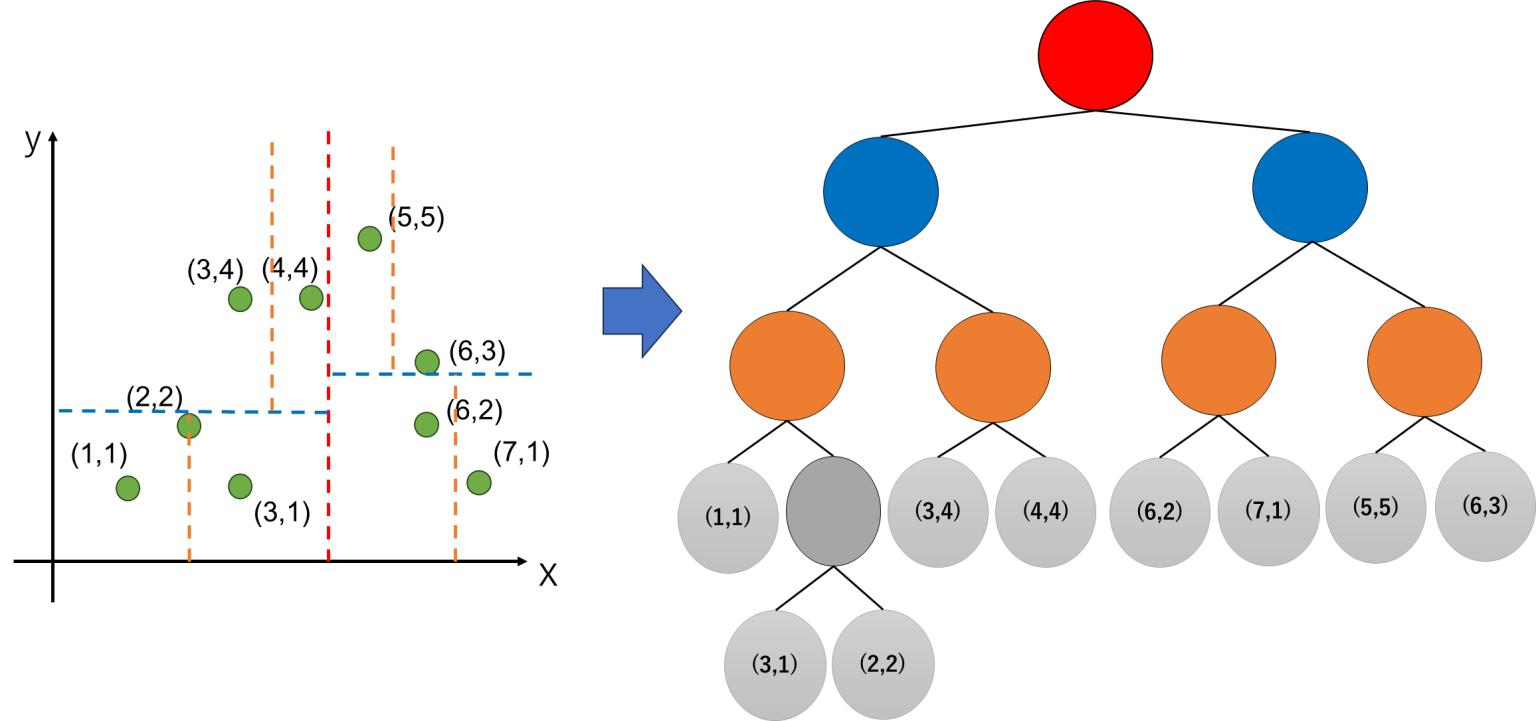

2.  **Ball Trees:**
    *   **Concept:** Similar to KD-Trees, Ball Trees are another space-partitioning data structure designed for efficient nearest neighbor searches. Instead of hyperrectangles, Ball Trees partition data points into nested hyperspheres (or 'balls'). Each node in the tree defines a hypersphere containing all the points in its subtree.
    *   **How it helps Lazy Learning:** When searching for neighbors, if the query point is outside a hypersphere or the distance to the query point is greater than the radius of the current best neighbor found, the entire subtree corresponding to that hypersphere can be ignored. This offers efficient pruning.
    *   **Benefit:** Often performs better than KD-Trees in higher-dimensional spaces and for datasets with complex distributions, as hyperspheres can sometimes enclose data more naturally than axis-aligned hyperrectangles.
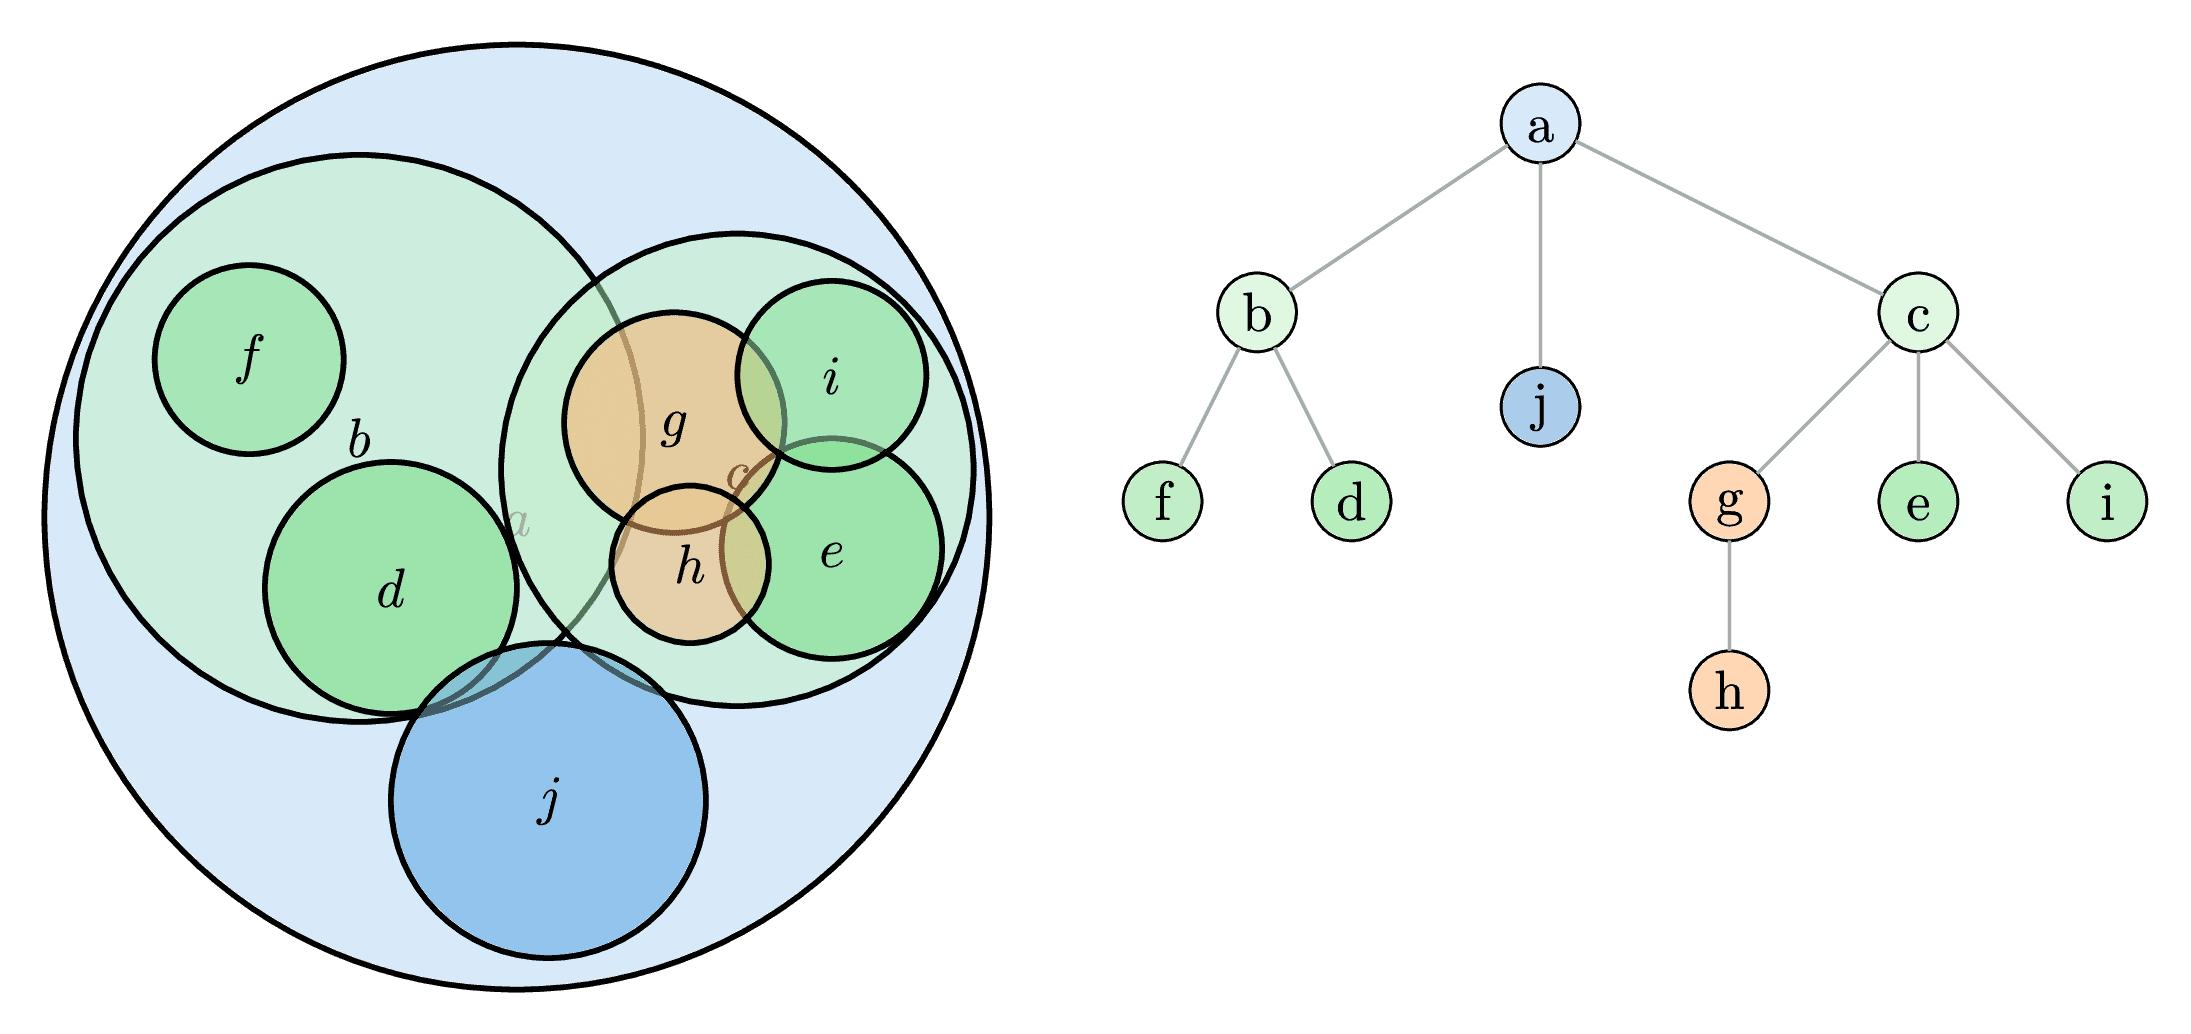


#### B. Weighted Lazy Learning (e.g., Weighted KNN)

*   **Concept:** As discussed in KNN extensions, this enhancement assigns different weights to neighbors based on their proximity to the query point. Closer neighbors contribute more significantly to the prediction than farther ones.
*   **How it helps Lazy Learning:** Improves prediction accuracy by making the local approximation more sensitive to the most relevant instances, effectively reducing the influence of potentially noisy or less representative distant neighbors.

#### C. Feature Selection and Dimensionality Reduction

*   **Why Needed:** Lazy learners are highly susceptible to the Curse of Dimensionality and irrelevant features. Reducing the number of dimensions or selecting the most informative features can dramatically improve performance.
*   **How it helps Lazy Learning:**
    *   **Reduces Memory:** Fewer features mean less data to store.
    *   **Speeds up Distance Calculation:** Distances are computed over fewer dimensions.
    *   **Improves Distance Meaningfulness:** By removing noise and redundancy, distances become more accurate reflections of similarity, making neighbor selection more reliable.

#### D. Locally Weighted Learning (LWL) / Locally Weighted Regression (LWR)

*   **Concept:** A generalization of lazy learning where, instead of just taking a simple majority vote or average, a *local model* (e.g., a local linear regression) is fit to the neighbors of the query point. The data points are weighted by their distance to the query point, giving more importance to closer points.
*   **How it helps Lazy Learning:** Can provide more sophisticated and accurate local approximations than simple averaging, especially for regression tasks, by capturing local trends more effectively.

These extensions transform basic lazy learning algorithms into more robust and efficient tools, making them applicable to a wider range of real-world problems despite their inherent 'laziness'.